# 2D Convolutional Neural Network from Scratch

Every model in this repository so far treated a row of data as a flat list of numbers. That throws
away something important about an image: which pixels are next to which. A convolutional network
keeps that information.

Instead of giving every pixel its own weight, a CNN slides a small grid of weights - a **filter** -
across the image and records how strongly it matches at each position. One filter might respond to
a vertical stroke, another to a corner. The same filter is used everywhere, so a stroke is
recognised wherever it appears, and a 3x3 filter only needs 9 numbers no matter how large the image.

The network built here is:

```
8x8 image
  -> convolution, 16 filters of 3x3   -> 6x6x16
  -> ReLU
  -> max pooling 2x2                  -> 3x3x16
  -> flatten                          -> 144
  -> dense layer                      -> 10
  -> softmax
```

That is 1,610 numbers to learn. Both the forward pass and the backward pass are written out below.
The data is the UCI handwritten digits set, where each sample really is an 8x8 image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue, orange = '#2a78d6', '#eb6834'

## Loading the data

`fetch_ucirepo(id=80)` downloads 5,620 handwritten digits. Each row holds 64 numbers, which is an
8x8 image flattened out, so `reshape(-1, 8, 8)` puts it back into a grid. Pixel values run from 0
to 16, and dividing by 16 puts them between 0 and 1.

The data is then shuffled and split 80/20.

In [2]:
digits = fetch_ucirepo(id=80)

X_all = digits.data.features.values.astype(float)
y_all = digits.data.targets.values.ravel()

# 64 numbers per row is really an 8x8 image
X_all = X_all.reshape(-1, 8, 8) / 16.0

rng = np.random.default_rng(0)
order = rng.permutation(len(X_all))
split = int(0.8 * len(X_all))

X_train, y_train = X_all[order[:split]], y_all[order[:split]]
X_test, y_test = X_all[order[split:]], y_all[order[split:]]

print('images:', X_all.shape)
print('train:', X_train.shape, ' test:', X_test.shape)
print('digits:', np.unique(y_all))

images: (5620, 8, 8)
train: (4496, 8, 8)  test: (1124, 8, 8)
digits: [0 1 2 3 4 5 6 7 8 9]


The cell below draws the first ten training images with their labels.

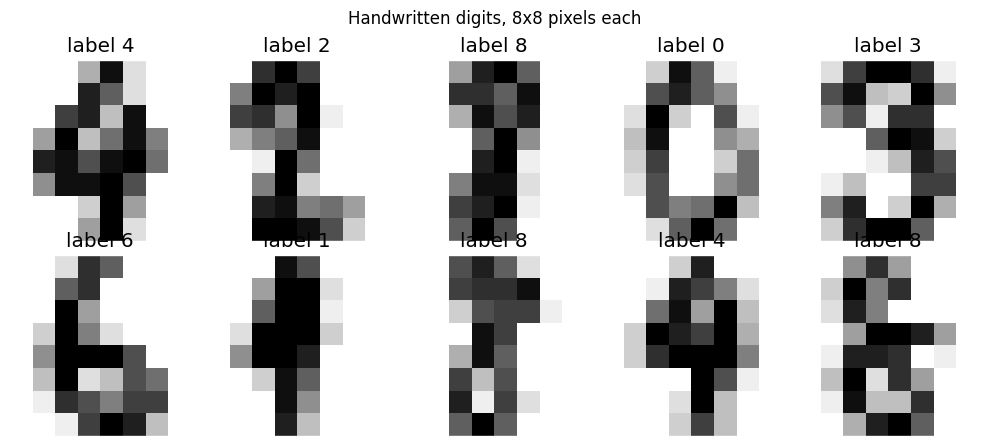

In [3]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))

for a, image, label in zip(ax.ravel(), X_train, y_train):
    a.imshow(image, cmap='gray_r')
    a.set_title(f'label {label}')
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)

plt.suptitle('Handwritten digits, 8x8 pixels each')
plt.tight_layout()
plt.show()

## What a convolution does

`conv_forward` slides each filter over the image. For every position it takes the 3x3 patch
sitting under the filter, multiplies it with the filter values and adds them up, giving one number.

On an 8x8 image a 3x3 filter fits in 6 positions across and 6 down, so each filter produces a 6x6
grid of responses called a **feature map**. With 16 filters the output is 6x6x16.

The loop runs over the 36 output positions rather than over the images. At each position it pulls
the same patch out of every image at once and multiplies it against all 16 filters in one matrix
product, so the whole batch is handled together.

In [4]:
def conv_forward(X, kernels, bias):
    n = len(X)
    f, kh, kw = kernels.shape
    out_h = X.shape[1] - kh + 1
    out_w = X.shape[2] - kw + 1

    out = np.zeros((n, out_h, out_w, f))
    flat_kernels = kernels.reshape(f, kh * kw)

    for i in range(out_h):
        for j in range(out_w):
            # the patch under the filter, taken from every image at once
            region = X[:, i:i + kh, j:j + kw].reshape(n, kh * kw)
            out[:, i, j, :] = region @ flat_kernels.T + bias

    return out

To show what that produces, the cell below applies two filters written by hand rather than learned.
The first has a positive column on the left and a negative one on the right, so it responds where
the image goes from bright to dark horizontally - a vertical edge. The second is the same idea
rotated, so it picks up horizontal edges.

The network is not given filters like these. It starts from random numbers and works out its own.

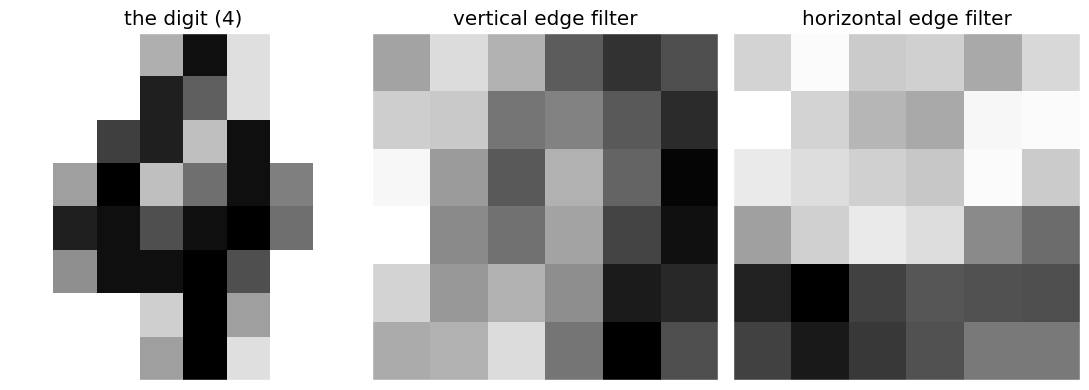

image shape : (1, 8, 8)
after conv  : (1, 6, 6, 2) (2 filters, each giving a 6x6 map)


In [5]:
vertical = np.array([[1., 0., -1.],
                     [1., 0., -1.],
                     [1., 0., -1.]])

horizontal = np.array([[1., 1., 1.],
                       [0., 0., 0.],
                       [-1., -1., -1.]])

hand_made = np.stack([vertical, horizontal])
digit = X_train[0:1]

maps = conv_forward(digit, hand_made, np.zeros(2))

fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
ax[0].imshow(digit[0], cmap='gray_r'); ax[0].set_title(f'the digit ({y_train[0]})')
ax[1].imshow(maps[0, :, :, 0], cmap='gray_r'); ax[1].set_title('vertical edge filter')
ax[2].imshow(maps[0, :, :, 1], cmap='gray_r'); ax[2].set_title('horizontal edge filter')

for a in ax:
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.tight_layout()
plt.show()

print('image shape :', digit.shape)
print('after conv  :', maps.shape, '(2 filters, each giving a 6x6 map)')

## Max pooling

Pooling shrinks a feature map by keeping only the strongest response in each small window. This
one takes 2x2 blocks and keeps the largest value, turning 6x6 into 3x3.

It does two things. It cuts the amount of data down, and it makes the answer less sensitive to
exactly where a stroke sits - shifting it by a pixel usually leaves the maximum of the block
unchanged.

In [6]:
def maxpool_forward(X):
    n, h, w, f = X.shape
    out = np.zeros((n, h // 2, w // 2, f))

    for i in range(h // 2):
        for j in range(w // 2):
            out[:, i, j, :] = X[:, i * 2:i * 2 + 2, j * 2:j * 2 + 2, :].max(axis=(1, 2))

    return out


def softmax(scores):
    # subtract the largest score first so exp does not overflow
    e = np.exp(scores - scores.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

## Going backwards

Training needs the derivative of the loss with respect to every filter value, which means each
step has to be reversed.

`conv_backward` answers: if the output at some position should have been higher, how should the
filter change? Since that output was `patch . filter`, the derivative with respect to the filter is
just the patch itself, scaled by the gradient arriving at that position. The loop walks the same 36
positions as the forward pass and accumulates.

`maxpool_backward` is simpler. Only the largest value in each 2x2 block was used, so only that one
gets gradient and the other three get zero. `argmax` finds which position won. It matters that
exactly one is picked: when a block contains several equal values, which happens constantly here
because the blank background is all zeros, handing gradient to all of them would count it several
times over.

In [7]:
def conv_backward(X, kernels, dout):
    n = len(X)
    f, kh, kw = kernels.shape
    out_h, out_w = dout.shape[1], dout.shape[2]

    dk = np.zeros((f, kh * kw))
    db = np.zeros(f)

    for i in range(out_h):
        for j in range(out_w):
            region = X[:, i:i + kh, j:j + kw].reshape(n, kh * kw)
            dk += dout[:, i, j, :].T @ region
            db += dout[:, i, j, :].sum(axis=0)

    return dk.reshape(f, kh, kw), db


def maxpool_backward(X, dout):
    n, h, w, f = X.shape
    dX = np.zeros_like(X)
    rows, cols = np.meshgrid(np.arange(n), np.arange(f), indexing='ij')

    for i in range(h // 2):
        for j in range(w // 2):
            window = X[:, i * 2:i * 2 + 2, j * 2:j * 2 + 2, :].reshape(n, 4, f)

            # only the winner of each block gets gradient, and only one winner
            winner = window.argmax(axis=1)
            mask = np.zeros_like(window)
            mask[rows, winner, cols] = 1

            dX[:, i * 2:i * 2 + 2, j * 2:j * 2 + 2, :] += (mask.reshape(n, 2, 2, f)
                                                           * dout[:, i:i + 1, j:j + 1, :])

    return dX

## The network

`__init__` creates the two sets of weights. The random values are scaled by `sqrt(2 / inputs)`,
which keeps the signal from growing or shrinking as it passes through the layers.

`forward` runs the image through convolution, ReLU, pooling, flattening and the dense layer,
keeping each intermediate result because the backward pass needs them.

`backward` starts from `probs - one hot`, which is the derivative of the softmax and the
cross-entropy loss taken together, then walks back through the same steps in reverse and subtracts
a small multiple of each gradient from the weights.

In [8]:
class CNN:
    def __init__(self, num_filters=16, learning_rate=0.1, seed=0):
        r = np.random.default_rng(seed)

        self.kernels = r.normal(0, np.sqrt(2 / 9), (num_filters, 3, 3))
        self.kernel_bias = np.zeros(num_filters)

        flat_size = 3 * 3 * num_filters
        self.weights = r.normal(0, np.sqrt(2 / flat_size), (flat_size, 10))
        self.bias = np.zeros(10)

        self.learning_rate = learning_rate

    def forward(self, X):
        self.X = X
        self.conv = conv_forward(X, self.kernels, self.kernel_bias)
        self.relu = np.maximum(0, self.conv)
        self.pool = maxpool_forward(self.relu)
        self.flat = self.pool.reshape(len(X), -1)
        self.scores = self.flat @ self.weights + self.bias
        return softmax(self.scores)

    def backward(self, probs, y):
        n = len(y)

        # derivative of softmax and cross-entropy together
        dscores = probs.copy()
        dscores[np.arange(n), y] -= 1
        dscores /= n

        dweights = self.flat.T @ dscores
        dbias = dscores.sum(axis=0)

        dflat = dscores @ self.weights.T
        dpool = dflat.reshape(self.pool.shape)
        drelu = maxpool_backward(self.relu, dpool)
        dconv = drelu * (self.conv > 0)
        dkernels, dkernel_bias = conv_backward(self.X, self.kernels, dconv)

        self.weights -= self.learning_rate * dweights
        self.bias -= self.learning_rate * dbias
        self.kernels -= self.learning_rate * dkernels
        self.kernel_bias -= self.learning_rate * dkernel_bias

    def predict(self, X):
        return self.forward(X).argmax(axis=1)

## Checking the derivatives

The backward pass is the easy part to get wrong, and a mistake there does not raise an error - the
network just trains badly.

The check is to nudge one weight up by a tiny amount, nudge it down, and see how much the loss
actually moved. That measured slope should match what `backward` calculated. The cell compares a
few of each kind of weight.

In [9]:
def loss_of(net, X, y):
    probs = net.forward(X)
    return -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()


check_net = CNN(num_filters=4, learning_rate=0.0)
Xb, yb = X_train[:12], y_train[:12]

# the gradients backward would compute
probs = check_net.forward(Xb)
dscores = probs.copy()
dscores[np.arange(len(yb)), yb] -= 1
dscores /= len(yb)
dweights = check_net.flat.T @ dscores
dflat = dscores @ check_net.weights.T
drelu = maxpool_backward(check_net.relu, dflat.reshape(check_net.pool.shape))
dkernels, _ = conv_backward(check_net.X, check_net.kernels, drelu * (check_net.conv > 0))

eps = 1e-5

def measured_slope(param, index):
    original = param[index]
    param[index] = original + eps
    up = loss_of(check_net, Xb, yb)
    param[index] = original - eps
    down = loss_of(check_net, Xb, yb)
    param[index] = original
    return (up - down) / (2 * eps)


print(f'{"weight":18s} {"from backward":>16s} {"measured":>16s}')
for index in [(2, 1, 0), (2, 2, 0), (0, 2, 1), (0, 0, 0)]:
    print(f'kernel {str(index):11s} {dkernels[index]:16.8f} {measured_slope(check_net.kernels, index):16.8f}')
for index in [(18, 3), (6, 3), (34, 3), (30, 3)]:
    print(f'dense  {str(index):11s} {dweights[index]:16.8f} {measured_slope(check_net.weights, index):16.8f}')

weight                from backward         measured
kernel (2, 1, 0)         0.68446575       0.68446575
kernel (2, 2, 0)         0.59162721       0.59162721
kernel (0, 2, 1)         0.48336707       0.48336707
kernel (0, 0, 0)         0.39665018       0.39665018
dense  (18, 3)           0.62057482       0.62057482
dense  (6, 3)            0.58101781       0.58101781
dense  (34, 3)           0.50196969       0.50196969
dense  (30, 3)           0.49337977       0.49337977


The two columns agree to eight decimal places, so the backward pass matches what the loss actually
does.

## Training

The loop goes over the training set 30 times. Each pass shuffles the data and works through it in
batches of 32, running `forward` then `backward` on each batch. Loss and accuracy on both the
training and test sets are recorded after every epoch.

In [10]:
def loss_and_accuracy(net, X, y, chunk=1000):
    total_loss = 0
    correct = 0
    for s in range(0, len(X), chunk):
        xb, yb = X[s:s + chunk], y[s:s + chunk]
        probs = net.forward(xb)
        total_loss += -np.log(probs[np.arange(len(yb)), yb] + 1e-12).sum()
        correct += (probs.argmax(axis=1) == yb).sum()
    return total_loss / len(X), correct / len(X)


net = CNN(num_filters=16, learning_rate=0.1)

train_loss, test_loss, train_acc, test_acc = [], [], [], []
batch_size = 32

for epoch in range(30):
    order = np.random.default_rng(epoch).permutation(len(X_train))
    for s in range(0, len(order), batch_size):
        batch = order[s:s + batch_size]
        probs = net.forward(X_train[batch])
        net.backward(probs, y_train[batch])

    tl, ta = loss_and_accuracy(net, X_train, y_train)
    vl, va = loss_and_accuracy(net, X_test, y_test)
    train_loss.append(tl); train_acc.append(ta)
    test_loss.append(vl); test_acc.append(va)

    if (epoch + 1) % 5 == 0:
        print(f'epoch {epoch+1:2d}  train loss {tl:.4f} acc {ta:.4f}  |  test loss {vl:.4f} acc {va:.4f}')

print()
print(f'Final test accuracy: {test_acc[-1]:.4f}')

epoch  5  train loss 0.1250 acc 0.9635  |  test loss 0.1526 acc 0.9520


epoch 10  train loss 0.0770 acc 0.9798  |  test loss 0.1111 acc 0.9733


epoch 15  train loss 0.1023 acc 0.9673  |  test loss 0.1520 acc 0.9520


epoch 20  train loss 0.0540 acc 0.9867  |  test loss 0.1077 acc 0.9733


epoch 25  train loss 0.0510 acc 0.9862  |  test loss 0.0899 acc 0.9715


epoch 30  train loss 0.0407 acc 0.9887  |  test loss 0.0793 acc 0.9786

Final test accuracy: 0.9786


## Accuracy graphs

Loss on the left, accuracy on the right, with the training and test curves on the same axes. The
gap between them shows how much better the network does on digits it has already seen than on new
ones.

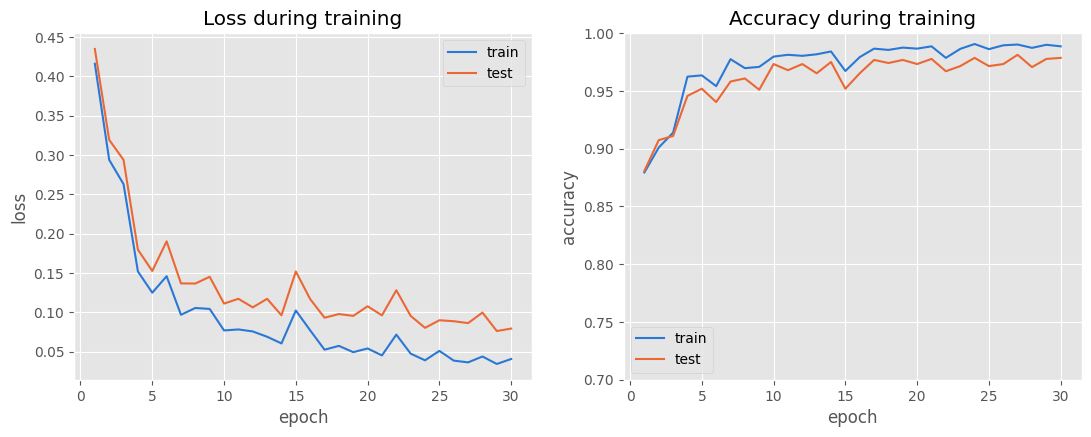

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

epochs = range(1, len(train_loss) + 1)

ax[0].plot(epochs, train_loss, color=blue, label='train')
ax[0].plot(epochs, test_loss, color=orange, label='test')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss')
ax[0].set_title('Loss during training')
ax[0].legend()

ax[1].plot(epochs, train_acc, color=blue, label='train')
ax[1].plot(epochs, test_acc, color=orange, label='test')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy')
ax[1].set_ylim(0.7, 1.0)
ax[1].set_title('Accuracy during training')
ax[1].legend()

plt.show()

## The filters it learned

These are the 16 filters, drawn as 3x3 images. Light squares are positive weights and dark squares
negative. A filter responds most strongly to a patch that looks like it.

They were random at the start. Several have ended up with light and dark sides, which is an edge
detector of the sort written by hand earlier - the network arrived at it on its own because that is
what separates the digits.

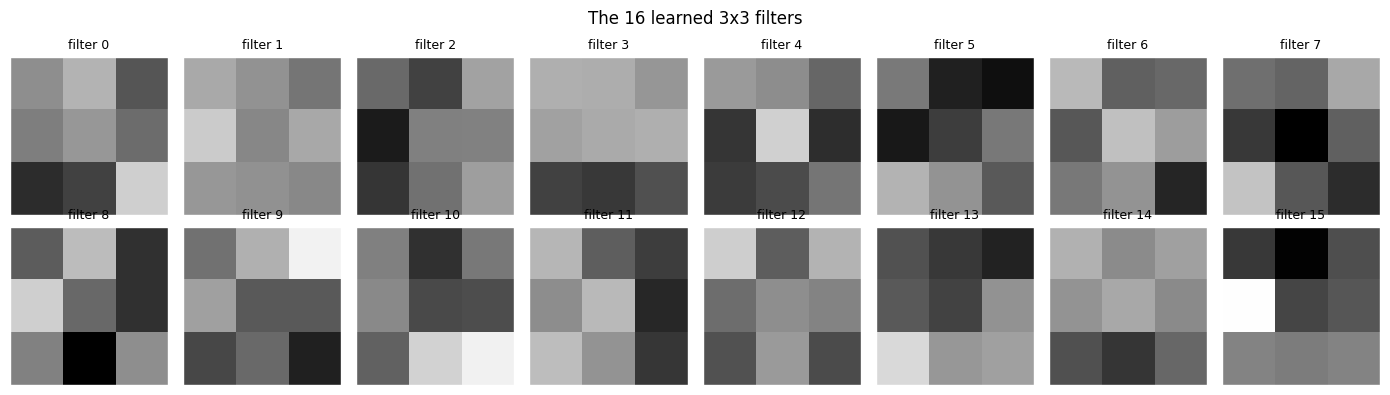

In [12]:
fig, ax = plt.subplots(2, 8, figsize=(14, 4))

limit = np.abs(net.kernels).max()
for a, kernel, index in zip(ax.ravel(), net.kernels, range(len(net.kernels))):
    a.imshow(kernel, cmap='gray_r', vmin=-limit, vmax=limit)
    a.set_title(f'filter {index}', fontsize=9)
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('The 16 learned 3x3 filters')
plt.tight_layout()
plt.show()

## What the filters see

The cell takes one digit and draws the feature map each learned filter produces after ReLU. Bright
areas are where that filter found what it responds to. Different filters light up on different
parts of the same digit.

Some panels come out blank. That is a filter which found nothing it responds to in this particular
digit, not a broken one - filter 1 is the most selective of the set and fires on under a tenth of
all positions across the test set, while filter 4 fires on almost nine tenths.

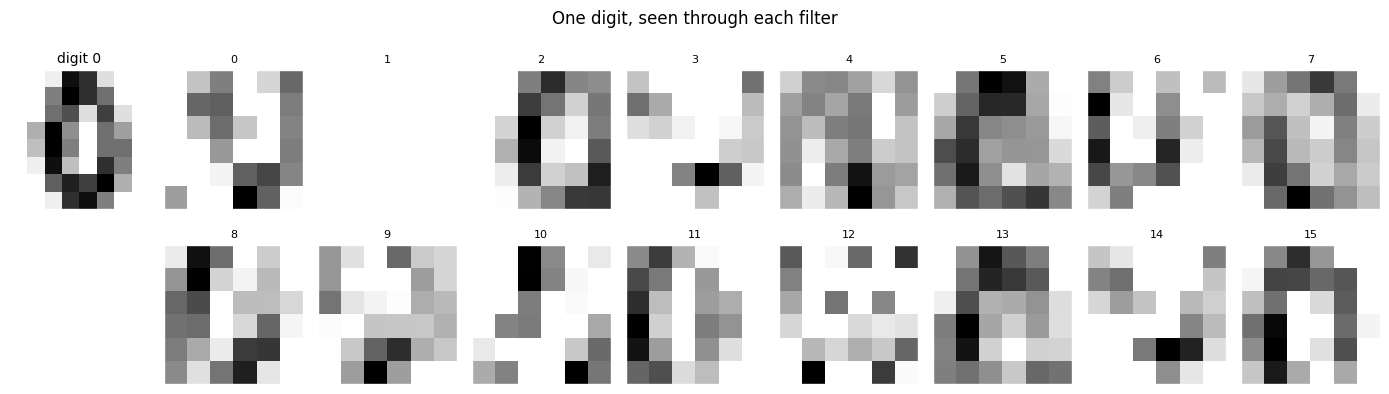

In [13]:
sample = X_test[0:1]
net.forward(sample)

fig = plt.figure(figsize=(14, 4.2))

a = plt.subplot(2, 9, 1)
a.imshow(sample[0], cmap='gray_r')
a.set_title(f'digit {y_test[0]}', fontsize=10)
a.set_xticks([]); a.set_yticks([]); a.grid(False)

for index in range(16):
    a = plt.subplot(2, 9, index + 2 + (index >= 8))
    a.imshow(net.relu[0, :, :, index], cmap='gray_r')
    a.set_title(f'{index}', fontsize=8)
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('One digit, seen through each filter')
plt.tight_layout()
plt.show()

## Where the mistakes are

The table counts every test digit by what it really was against what the network said. The diagonal
is the correct answers.

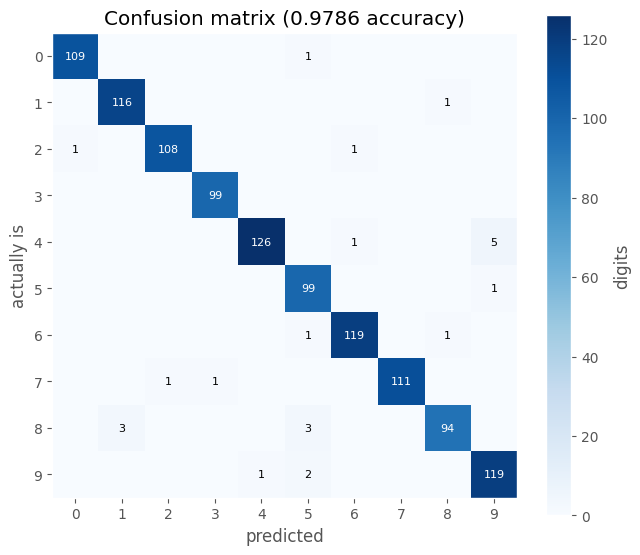

most common mix-ups:
  4 called 9: 5 times
  8 called 5: 3 times
  8 called 1: 3 times
  9 called 5: 2 times
  9 called 4: 1 times


In [14]:
predictions = net.predict(X_test)

table = np.zeros((10, 10), dtype=int)
for true, guess in zip(y_test, predictions):
    table[true, guess] += 1

plt.figure(figsize=(7.5, 6.5))
plt.imshow(table, cmap='Blues')
for i in range(10):
    for j in range(10):
        if table[i, j] > 0:
            plt.text(j, i, table[i, j], ha='center', va='center', fontsize=8,
                     color='white' if table[i, j] > table.max() / 2 else 'black')
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel('predicted'); plt.ylabel('actually is')
plt.title(f'Confusion matrix ({(predictions == y_test).mean():.4f} accuracy)')
plt.colorbar(label='digits')
plt.grid(False)
plt.show()

confused = [(table[i, j], i, j) for i in range(10) for j in range(10) if i != j]
print('most common mix-ups:')
for count, true, guess in sorted(confused, reverse=True)[:5]:
    print(f'  {true} called {guess}: {count} times')

## The ones it got wrong

Every test digit the network misread, with the true label and its guess. Most of them are genuinely
unclear at 8x8.

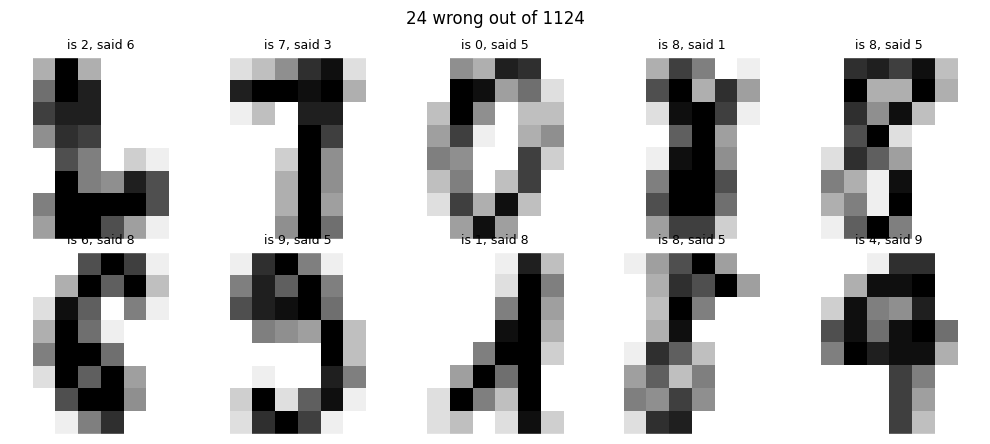

In [15]:
wrong = np.where(predictions != y_test)[0][:10]

fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))

for a, index in zip(ax.ravel(), wrong):
    a.imshow(X_test[index], cmap='gray_r')
    a.set_title(f'is {y_test[index]}, said {predictions[index]}', fontsize=9)
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

for a in ax.ravel()[len(wrong):]:
    a.axis('off')

plt.suptitle(f'{(predictions != y_test).sum()} wrong out of {len(y_test)}')
plt.tight_layout()
plt.show()

## Summary

- A convolution slides a small filter across the image and records how strongly it matches at each
  position, so the same pattern is recognised wherever it appears and a 3x3 filter costs 9 weights
  regardless of image size.
- Max pooling keeps the strongest response in each 2x2 block, shrinking the data and making the
  result less sensitive to a stroke moving by a pixel.
- The backward pass is the whole thing in reverse: the gradient for a filter is the patch it was
  looking at, and pooling passes gradient back only to the value that won its block.
- The finite-difference check confirms the hand-written derivatives agree with the loss to eight
  decimal places.
- With 16 filters and 1,610 weights it reaches **97.9%** on the held-out digits after 30 epochs,
  taking a couple of seconds to train.
- The filters were never told what to look for. Several came out as edge detectors on their own.